Static cropping

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

RAW_VIDEO = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_final_sync.mp4'

# Extract the first frame
cap = cv2.VideoCapture(RAW_VIDEO)
ret, frame = cap.read()
cap.release()

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(30, 16), dpi=300)
    ax.imshow(frame)
    
    # Draw 200px grid
    ax.set_xticks(range(0, frame.shape[1], 200))
    ax.set_yticks(range(0, frame.shape[0], 200))
    ax.grid(color='red', linestyle='-', linewidth=1, alpha=0.7)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.savefig('trial3_grid_reference.png', bbox_inches='tight', pad_inches=0.1)
    print("✅ Grid saved as 'trial3_grid_reference.png'. Open it to find your crop coordinates.")
else:
    print("❌ Failed to read video.")

Once you check the grid image, run this cell using the ! bash command. Replace the W:H:X:Y variables with your actual crop dimensions (e.g., crop=2000:2160:900:0 if you want a 2000px wide video starting at X=900).

%%bash
# Replace W:H:X:Y with your grid coordinates
ffmpeg -y -i /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_final_sync.mp4 \
-filter:v "crop=W:H:X:Y" \
-c:a copy \
/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_static_crop.mp4

Cell 3: Stage 1 Setup (The Tracker)
Initializes the project to track only TailBase.

In [ ]:
import deeplabcut
import ruamel.yaml
import os

WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/Scripts'
STATIC_VIDEO = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_static_crop.mp4'

print("⚙️ Initializing Stage 1 Project...")
stage1_config = deeplabcut.create_new_project(
    'Stage1_Tracker', 'Dev', [STATIC_VIDEO], 
    working_directory=WORKING_DIR, copy_videos=False
)

# Edit config for single point tracking and MobileNet
ryaml = ruamel.yaml.YAML()
ryaml.preserve_quotes = True
with open(stage1_config, 'r') as f:
    cfg = ryaml.load(f)

cfg['bodyparts'] = ['TailBase']
cfg['skeleton'] = [] # No skeleton needed for a single point
cfg['default_net_type'] = 'mobilenet_v2_1.0'
cfg['numframes2pick'] = 100

with open(stage1_config, 'w') as f:
    ryaml.dump(cfg, f)

print(f"✅ Stage 1 initialized. Extracting frames...")
deeplabcut.extract_frames(stage1_config, mode='automatic', algo='kmeans', userfeedback=False)

Cell 4: Stage 1 Parse & Train
(Assumption: You have labeled the Stage 1 frames in Label Studio and downloaded the CSV). Update the LS_CSV path, then run this block to train the tracker and analyze the static video.

In [ ]:
import pandas as pd
import json
import numpy as np
import deeplabcut
import glob
import re
import yaml

LS_CSV = '/path/to/your/stage1_labelstudio_export.csv'
VIDEO_NAME = '20260121_SERt3tp_static_crop'
PROJECT_PATH = os.path.dirname(stage1_config)

# --- 1. Parser ---
df_ls = pd.read_csv(LS_CSV)
data_rows = []
for _, row in df_ls.iterrows():
    fname = os.path.basename(row['image']).split('-')[-1] if '-' in row['image'] else os.path.basename(row['image'])
    frame_data = {'image': f"labeled-data/{VIDEO_NAME}/{fname}", 'TailBase_x': np.nan, 'TailBase_y': np.nan}
    try:
        labels = json.loads(row['label' if 'label' in df_ls.columns else 'annotation'])
        if isinstance(labels, list) and 'result' in labels[0]: labels = labels[0]['result']
        for l in labels:
            v = l.get('value', {})
            if v.get('keypointlabels', [None])[0] == 'TailBase':
                frame_data['TailBase_x'] = (v['x'] * v.get('original_width', 3840)) / 100.0
                frame_data['TailBase_y'] = (v['y'] * v.get('original_height', 2160)) / 100.0
    except: pass
    data_rows.append(frame_data)

df_final = pd.DataFrame(data_rows).set_index('image')
df_final.columns = pd.MultiIndex.from_product([['Dev'], ['TailBase'], ['x', 'y']], names=['scorer', 'bodyparts', 'coords'])
frame_dest = os.path.join(PROJECT_PATH, 'labeled-data', VIDEO_NAME)
df_final.to_hdf(os.path.join(frame_dest, 'CollectedData_Dev.h5'), key='df_with_missing', mode='w')
df_final.to_csv(os.path.join(frame_dest, 'CollectedData_Dev.csv'))

# --- 2. Dataset & Posix Patch ---
def posix_path_constructor(loader, node):
    if isinstance(node, yaml.ScalarNode): return str(loader.construct_scalar(node))
    elif isinstance(node, yaml.SequenceNode): return str(loader.construct_sequence(node)[0])
    return str(node.value)
yaml.SafeLoader.add_constructor('tag:yaml.org,2002:python/object/apply:pathlib.PosixPath', posix_path_constructor)

deeplabcut.create_training_dataset(stage1_config, net_type='mobilenet_v2_1.0', augmenter_type='default')

# --- 3. VRAM Limits ---
for p in glob.glob(os.path.join(PROJECT_PATH, 'dlc-models', '*', '*', '*', 'pose_cfg.yaml'), recursive=True):
    with open(p, 'r') as f: text = f.read()
    text = re.sub(r'^global_scale:\s*.*$', 'global_scale: 0.4', text, flags=re.MULTILINE)
    if 'train' in p: text = re.sub(r'^batch_size:\s*.*$', 'batch_size: 2', text, flags=re.MULTILINE)
    with open(p, 'w') as f: f.write(text)

# --- 4. Train & Analyze ---
deeplabcut.train_network(stage1_config, maxiters=50000, displayiters=1000, allow_growth=True)
deeplabcut.analyze_videos(stage1_config, [STATIC_VIDEO], save_as_csv=True, batchsize=2)

Cell 5: The Dynamic Cropping Engine
This reads the output from Stage 1. It cuts an 800x800 box centered on TailBase for every frame and writes the _dynamic_crop.mp4. It also saves crop_offsets.csv so we can map the coordinates back later.

In [ ]:
import cv2
import pandas as pd
import numpy as np

# Find the Stage 1 analysis CSV
csv_files = glob.glob(os.path.join(os.path.dirname(STATIC_VIDEO), f'{VIDEO_NAME}DLC*.csv'))
track_csv = sorted(csv_files)[-1] # Gets the latest one

df = pd.read_csv(track_csv, header=[1, 2], index_col=0)
x_coords = df[('TailBase', 'x')].values
y_coords = df[('TailBase', 'y')].values

CROP_SIZE = 800
offsets = []

cap = cv2.VideoCapture(STATIC_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_path = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_dynamic_crop.mp4'
out = cv2.VideoWriter(out_path, fourcc, fps, (CROP_SIZE, CROP_SIZE))

frame_idx = 0
print("✂️ Generating dynamically cropped video...")
while True:
    ret, frame = cap.read()
    if not ret: break
    
    h, w, _ = frame.shape
    x, y = x_coords[frame_idx], y_coords[frame_idx]
    
    # Fallback to center if tracking failed
    if np.isnan(x) or np.isnan(y): 
        x, y = w//2, h//2

    # Calculate top-left bounding box coordinates
    x1 = int(max(0, x - CROP_SIZE//2))
    y1 = int(max(0, y - CROP_SIZE//2))
    
    # Constrain to frame boundaries
    if x1 + CROP_SIZE > w: x1 = w - CROP_SIZE
    if y1 + CROP_SIZE > h: y1 = h - CROP_SIZE
    
    cropped = frame[y1:y1+CROP_SIZE, x1:x1+CROP_SIZE]
    out.write(cropped)
    
    offsets.append({'frame': frame_idx, 'x_offset': x1, 'y_offset': y1})
    frame_idx += 1

cap.release()
out.release()

pd.DataFrame(offsets).to_csv(os.path.join(os.path.dirname(STATIC_VIDEO), 'crop_offsets.csv'), index=False)
print(f"✅ Dynamic video saved to {out_path}\n✅ Offsets saved to crop_offsets.csv")

Cell 6: Stage 2 Setup (The Fine Model)
Initializes the final project on the dynamically cropped video. Extracts frames for your detailed labeling.

In [ ]:
DYNAMIC_VIDEO = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_dynamic_crop.mp4'

print("⚙️ Initializing Stage 2 Project...")
stage2_config = deeplabcut.create_new_project(
    'Stage2_Fine', 'Dev', [DYNAMIC_VIDEO], 
    working_directory=WORKING_DIR, copy_videos=False
)

with open(stage2_config, 'r') as f: cfg = ryaml.load(f)

cfg['bodyparts'] = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']
cfg['skeleton'] = [['Snout', 'DorsalFin'], ['DorsalFin', 'TailBase'], ['TailBase', 'TailTip']]
cfg['default_net_type'] = 'mobilenet_v2_1.0'
cfg['numframes2pick'] = 150

with open(stage2_config, 'w') as f: ryaml.dump(cfg, f)

print(f"✅ Stage 2 initialized. Extracting frames...")
deeplabcut.extract_frames(stage2_config, mode='automatic', algo='kmeans', userfeedback=False)

Cell 7: Stage 2 Parse & Train
(Assumption: You have labeled the Stage 2 frames and have the CSV). Update LS_CSV_STAGE2. Notice the increased batch size and global scale since the video is much smaller and we are using MobileNet.

In [ ]:
LS_CSV_STAGE2 = '/path/to/your/stage2_labelstudio_export.csv'
S2_VIDEO_NAME = '20260121_SERt3tp_dynamic_crop'
S2_PROJECT_PATH = os.path.dirname(stage2_config)
bodyparts = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']

# --- 1. Parser ---
df_ls = pd.read_csv(LS_CSV_STAGE2)
data_rows = []
for _, row in df_ls.iterrows():
    fname = os.path.basename(row['image']).split('-')[-1] if '-' in row['image'] else os.path.basename(row['image'])
    frame_data = {'image': f"labeled-data/{S2_VIDEO_NAME}/{fname}"}
    for bp in bodyparts: frame_data[f'{bp}_x'], frame_data[f'{bp}_y'] = np.nan, np.nan
    try:
        labels = json.loads(row['label' if 'label' in df_ls.columns else 'annotation'])
        if isinstance(labels, list) and 'result' in labels[0]: labels = labels[0]['result']
        for l in labels:
            v = l.get('value', {})
            bp = v.get('keypointlabels', [None])[0]
            if bp in bodyparts:
                frame_data[f'{bp}_x'] = (v['x'] * v.get('original_width', 800)) / 100.0
                frame_data[f'{bp}_y'] = (v['y'] * v.get('original_height', 800)) / 100.0
    except: pass
    data_rows.append(frame_data)

df_final = pd.DataFrame(data_rows).set_index('image')
df_final.columns = pd.MultiIndex.from_product([['Dev'], bodyparts, ['x', 'y']], names=['scorer', 'bodyparts', 'coords'])
frame_dest = os.path.join(S2_PROJECT_PATH, 'labeled-data', S2_VIDEO_NAME)
df_final.to_hdf(os.path.join(frame_dest, 'CollectedData_Dev.h5'), key='df_with_missing', mode='w')
df_final.to_csv(os.path.join(frame_dest, 'CollectedData_Dev.csv'))

# --- 2. Dataset Setup ---
deeplabcut.create_training_dataset(stage2_config, net_type='mobilenet_v2_1.0', augmenter_type='default')

# --- 3. VRAM Patches (Increased capability) ---
for p in glob.glob(os.path.join(S2_PROJECT_PATH, 'dlc-models', '*', '*', '*', 'pose_cfg.yaml'), recursive=True):
    with open(p, 'r') as f: text = f.read()
    text = re.sub(r'^global_scale:\s*.*$', 'global_scale: 0.8', text, flags=re.MULTILINE) # Higher res for tiny crop
    if 'train' in p: text = re.sub(r'^batch_size:\s*.*$', 'batch_size: 4', text, flags=re.MULTILINE) # Bumped
    with open(p, 'w') as f: f.write(text)

# --- 4. Train & Analyze ---
deeplabcut.train_network(stage2_config, maxiters=80000, displayiters=1000, allow_growth=True)
deeplabcut.analyze_videos(stage2_config, [DYNAMIC_VIDEO], save_as_csv=True, batchsize=4)
deeplabcut.create_labeled_video(stage2_config, [DYNAMIC_VIDEO], draw_skeleton=True)

Cell 8: Projection Mapping (The Final Printout)
This block takes the Stage 2 coordinates and adds the offsets from Cell 5, giving you the absolute X,Y tracking points as if they were predicted on the full video.

In [ ]:
# Load the offsets
offsets_df = pd.read_csv(os.path.join(os.path.dirname(STATIC_VIDEO), 'crop_offsets.csv'))

# Find the Stage 2 analysis CSV
s2_csv_files = glob.glob(os.path.join(os.path.dirname(STATIC_VIDEO), f'{S2_VIDEO_NAME}DLC*.csv'))
s2_track_csv = sorted(s2_csv_files)[-1]

# Load predictions
df_s2 = pd.read_csv(s2_track_csv, header=[0, 1, 2], index_col=0)
scorer = df_s2.columns[0][0]

# Add offsets back to the predictions
for bp in bodyparts:
    df_s2[(scorer, bp, 'x')] += offsets_df['x_offset'].values
    df_s2[(scorer, bp, 'y')] += offsets_df['y_offset'].values

# Save the absolute coordinate CSV
final_out = os.path.join(os.path.dirname(STATIC_VIDEO), 'FINAL_ABSOLUTE_TRACKING.csv')
df_s2.to_csv(final_out)
print(f"✅ Absolute tracking data restored and saved to: {final_out}")

Everything below here is dev pipeline:

In [2]:
import pandas as pd
import numpy as np
import cv2
import os

# --- Paths ---
CSV_PATH = '/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_t7w1_redlinear_GX010260_MASKEDDLC_resnet50_Cloud_Deployment_SERMar28shuffle1_80000.csv'
VIDEO_PATH = '/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_t7w1_redlinear_GX010260_MASKED.MP4'
OUT_VIDEO = '/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_crop.mp4'
OUT_OFFSETS = '/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/crop_offsets.csv'

CROP_SIZE = 800
Y_CROP_OFFSET = 700  # <--- The missing translation 

print("📊 Calculating robust trajectory with Y-offset...")
df = pd.read_csv(CSV_PATH, header=[1, 2], index_col=0)
bodyparts = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']

centroids_x = []
centroids_y = []

for idx, row in df.iterrows():
    xs, ys = [], []
    for bp in bodyparts:
        # Only consider points the model is at least 5% sure about
        if row[(bp, 'likelihood')] > 0.05:
            xs.append(row[(bp, 'x')])
            ys.append(row[(bp, 'y')] + Y_CROP_OFFSET) # <--- Applied here
    
    # Use median to ignore severe outliers
    if len(xs) >= 2:
        centroids_x.append(np.median(xs))
        centroids_y.append(np.median(ys))
    elif len(xs) == 1:
        centroids_x.append(xs[0])
        centroids_y.append(ys[0])
    else:
        centroids_x.append(np.nan)
        centroids_y.append(np.nan)

# Create a dataframe for the trajectory, interpolate missing frames, and smooth it
traj_df = pd.DataFrame({'x': centroids_x, 'y': centroids_y})
traj_df = traj_df.interpolate(method='linear', limit_direction='both')
traj_df['x'] = traj_df['x'].rolling(window=15, center=True, min_periods=1).mean()
traj_df['y'] = traj_df['y'].rolling(window=15, center=True, min_periods=1).mean()

print("✂️ Generating stabilized dynamic crop video...")
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUT_VIDEO, fourcc, fps, (CROP_SIZE, CROP_SIZE))

offsets = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret: break
    
    h, w, _ = frame.shape
    
    # Get smoothed centroid coordinates
    cx = traj_df['x'].iloc[frame_idx]
    cy = traj_df['y'].iloc[frame_idx]
    
    # Calculate top-left bounding box coordinates
    x1 = int(max(0, cx - CROP_SIZE // 2))
    y1 = int(max(0, cy - CROP_SIZE // 2))
    
    # Keep the box inside the frame boundaries
    if x1 + CROP_SIZE > w: x1 = w - CROP_SIZE
    if y1 + CROP_SIZE > h: y1 = h - CROP_SIZE
    
    cropped = frame[y1:y1+CROP_SIZE, x1:x1+CROP_SIZE]
    out.write(cropped)
    
    offsets.append({'frame': frame_idx, 'x_offset': x1, 'y_offset': y1})
    frame_idx += 1

cap.release()
out.release()

pd.DataFrame(offsets).to_csv(OUT_OFFSETS, index=False)
print(f"✅ Dynamic video saved to {OUT_VIDEO}")
print(f"✅ Offsets saved to {OUT_OFFSETS}")

📊 Calculating robust trajectory with Y-offset...
✂️ Generating stabilized dynamic crop video...
✅ Dynamic video saved to /mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_crop.mp4
✅ Offsets saved to /mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/crop_offsets.csv


In [1]:
import deeplabcut
import ruamel.yaml
import os

WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/Scripts'
DYNAMIC_VIDEO = '/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_crop.mp4'

print("⚙️ Initializing Stage 2 (Fine Tracking) Project...")
stage2_config = deeplabcut.create_new_project(
    'Stage2_Fine_RedLinear', 'Dev', [DYNAMIC_VIDEO], 
    working_directory=WORKING_DIR, copy_videos=False
)

# Edit config for the 4-point setup and MobileNet
ryaml = ruamel.yaml.YAML()
ryaml.preserve_quotes = True
with open(stage2_config, 'r') as f:
    cfg = ryaml.load(f)

cfg['bodyparts'] = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']
cfg['skeleton'] = [['Snout', 'DorsalFin'], ['DorsalFin', 'TailBase'], ['TailBase', 'TailTip']]
cfg['default_net_type'] = 'mobilenet_v2_1.0'
cfg['numframes2pick'] = 150

with open(stage2_config, 'w') as f:
    ryaml.dump(cfg, f)

print(f"✅ Stage 2 initialized at {stage2_config}")
print("📸 Extracting 150 frames for labeling...")

deeplabcut.extract_frames(stage2_config, mode='automatic', algo='kmeans', userfeedback=False)

print("\n🎉 Extraction complete! The frames are ready for Label Studio.")

2026-03-31 09:24:16.657308: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 09:24:16.770785: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 09:24:17.449499: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loading DLC 2.3.11...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚙️ Initializing Stage 2 (Fine Tracking) Project...
Created "/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Fine_RedLinear-Dev-2026-03-31/videos"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Fine_RedLinear-Dev-2026-03-31/labeled-data"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Fine_RedLinear-Dev-2026-03-31/training-datasets"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Fine_RedLinear-Dev-2026-03-31/dlc-models"
Attempting to create a symbolic link of the video ...
Created the symlink of /mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_crop.mp4 to /mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Fine_RedLinear-Dev-2026-03-31/videos/20260318SER_dynamic_crop.mp4
/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Fine_RedLinear-Dev-2026-03-31/videos/20260318SER_dynamic_crop.mp4
Generated "/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Fine_RedLinear-Dev-2026-03-31/config.yaml"

A new project with name Stag

4983it [00:14, 339.04it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).

🎉 Extraction complete! The frames are ready for Label Studio.


In [1]:
import pandas as pd
import json
import os
import numpy as np
import glob
import deeplabcut

# --- SETTINGS (Updated for tonight's Redux project) ---
csv_file = os.path.expanduser('~/Downloads/project-11-at-2026-03-31-13-47-72d362b6.csv')
project_path = '/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Redux-Dev-2026-03-31'
config_path = os.path.join(project_path, 'config.yaml')
video_name = '20260318SER_dynamic_crop'

scorer = 'Dev'
bodyparts = ['Snout', 'DorsalFin', 'TailBase', 'TailTip'] 

print("⚙️ Parsing Label Studio CSV using your golden parser...")
df_ls = pd.read_csv(csv_file)
data_dict = {}

# --- STEP 1: PARSE AND CONVERT ---
for idx, row in df_ls.iterrows():
    json_col = 'label' if 'label' in df_ls.columns else 'annotation'
    labels_str = row.get(json_col, '')
    img_path_raw = str(row.get('image', ''))
    
    # Clean filename to ensure it matches DLC's img0000.png format
    fname = os.path.basename(img_path_raw).split('-')[-1] if '-' in img_path_raw else os.path.basename(img_path_raw)
    if fname.startswith('img') and fname.endswith('.png'):
        num = ''.join(filter(str.isdigit, fname))
        fname = f"img{int(num):04d}.png"
        
    rel_path = f"labeled-data/{video_name}/{fname}"
    
    frame_data = {'image': rel_path}
    for bp in bodyparts:
        frame_data[f'{bp}_x'] = np.nan
        frame_data[f'{bp}_y'] = np.nan
        
    if pd.notna(labels_str) and isinstance(labels_str, str):
        try:
            labels = json.loads(labels_str)
            # Handle LS wrapping the result in a list of dicts
            if isinstance(labels, list) and len(labels) > 0 and 'result' in labels[0]:
                labels = labels[0]['result']
                
            for label in labels:
                # Handle nested 'value' structure if it exists
                val = label.get('value', label) 
                
                if 'keypointlabels' in val and len(val['keypointlabels']) > 0:
                    bp = val['keypointlabels'][0]
                    if bp in bodyparts:
                        w = val.get('original_width', 600)
                        h = val.get('original_height', 600)
                        frame_data[f'{bp}_x'] = (val['x'] * w) / 100.0
                        frame_data[f'{bp}_y'] = (val['y'] * h) / 100.0
        except json.JSONDecodeError:
            pass
            
    if video_name not in data_dict:
        data_dict[video_name] = []
    data_dict[video_name].append(frame_data)

# --- STEP 2: BUILD HDF5 MULTI-INDEX ---
for video_folder, rows in data_dict.items():
    df_video = pd.DataFrame(rows)
    df_video.set_index('image', inplace=True)
    
    multi_cols = pd.MultiIndex.from_product([[scorer], bodyparts, ['x', 'y']], names=['scorer', 'bodyparts', 'coords'])
    
    final_data = []
    for bp in bodyparts:
        final_data.append(df_video[f'{bp}_x'])
        final_data.append(df_video[f'{bp}_y'])
        
    df_final = pd.concat(final_data, axis=1)
    df_final.columns = multi_cols
    
    output_dir = os.path.join(project_path, 'labeled-data', video_folder)
    os.makedirs(output_dir, exist_ok=True)
    
    h5_path = os.path.join(output_dir, f'CollectedData_{scorer}.h5')
    csv_path = os.path.join(output_dir, f'CollectedData_{scorer}.csv')
    
    df_final.to_hdf(h5_path, key='df_with_missing', mode='w')
    df_final.to_csv(csv_path)
    print(f"✅ Saved {len(df_final)} formatted frames to {h5_path}")

# --- STEP 3: CLEAR OLD MANIFESTS & BUILD NEW DATASET ---
print("\n🧹 Sweeping old broken datasets...")
os.system(f"rm -rf {project_path}/training-datasets/*")

print("🚀 Generating training dataset...")
# Using efficientnet-b0 to avoid the TF1 403 errors we hit earlier
deeplabcut.create_training_dataset(config_path, net_type='efficientnet-b0')

# Apply batch size patch for 3070 Ti VRAM constraints
print("🔧 Applying batch_size: 1 for VRAM safety...")
pose_cfgs = glob.glob(os.path.join(project_path, 'dlc-models', '*', '*', '*', 'pose_cfg.yaml'), recursive=True)
if pose_cfgs:
    with open(pose_cfgs[0], 'r') as f: lines = f.readlines()
    with open(pose_cfgs[0], 'w') as f:
        for line in lines:
            f.write('batch_size: 1\n' if line.strip().startswith('batch_size:') else line)

print("\n🔥 Starting Training Run...")
deeplabcut.train_network(config_path, displayiters=1000, maxiters=80000, allow_growth=True)

2026-03-31 10:10:52.919476: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 10:10:52.951051: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 10:10:53.406139: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loading DLC 2.3.11...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Config:
{'all_joints': [[0], [1], [2], [3]],
 'all_joints_names': ['Snout', 'DorsalFin', 'TailBase', 'TailTip'],
 'alpha_r': 0.02,
 'apply_prob': 0.5,
 'batch_size': 1,
 'contrast': {'clahe': True,
              'claheratio': 0.1,
              'histeq': True,
              'histeqratio': 0.1},
 'convolution': {'edge': False,
                 'emboss': {'alpha': [0.0, 1.0], 'strength': [0.5, 1.5]},
                 'embossratio': 0.1,
                 'sharpen': False,
                 'sharpenratio': 0.3},
 'crop_pad': 0,
 'cropratio': 0.4,
 'dataset': 'training-datasets/iteration-0/UnaugmentedDataSet_Stage2_ReduxMar31/Stage2_Redux_Dev95shuffle1.mat',
 'dataset_type': 'default',
 'decay_steps': 30000,
 'deterministic': Fals

⚙️ Parsing Label Studio CSV using your golden parser...
✅ Saved 133 formatted frames to /mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Redux-Dev-2026-03-31/labeled-data/20260318SER_dynamic_crop/CollectedData_Dev.h5

🧹 Sweeping old broken datasets...
🚀 Generating training dataset...
The training dataset is successfully created. Use the function 'train_network' to start training. Happy training!
🔧 Applying batch_size: 1 for VRAM safety...

🔥 Starting Training Run...
Selecting single-animal trainer
Batch Size is 1


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
2026-03-31 10:11:00.497987: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 10:11:00.499940: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 10:11:00.501648: 

...

Switching to cosine decay schedule with adam!


2026-03-31 10:11:01.975748: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:353] MLIR V1 optimization pass is not enabled
2026-03-31 10:11:04.955289: W tensorflow/c/c_api.cc:300] Operation '{name:'efficientnet/efficientnet-b0/blocks_4/conv2d_1/kernel/Assign' id:851 op device:{requested: '', assigned: ''} def:{{{node efficientnet/efficientnet-b0/blocks_4/conv2d_1/kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](efficientnet/efficientnet-b0/blocks_4/conv2d_1/kernel, efficientnet/efficientnet-b0/blocks_4/conv2d_1/kernel/Initializer/random_normal)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-03-31 10:11:05.073478: W tensorflow/c/c_api.cc:300] Operation '{name:'pose/locref_pred/block4/biases/Adam_1/Assign' id:9816 op device:{requested: '', assigned

Max_iters overwritten as 80000
Display_iters overwritten as 1000
Training parameter:
{'stride': 8.0, 'weigh_part_predictions': False, 'weigh_negatives': False, 'fg_fraction': 0.25, 'mean_pixel': [123.68, 116.779, 103.939], 'shuffle': True, 'snapshot_prefix': '/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Redux-Dev-2026-03-31/dlc-models/iteration-0/Stage2_ReduxMar31-trainset95shuffle1/train/snapshot', 'log_dir': 'log', 'global_scale': 0.8, 'location_refinement': True, 'locref_stdev': 7.2801, 'locref_loss_weight': 0.05, 'locref_huber_loss': True, 'optimizer': 'adam', 'intermediate_supervision': False, 'intermediate_supervision_layer': 12, 'regularize': False, 'weight_decay': 0.0001, 'crop_pad': 0, 'scoremap_dir': 'test', 'batch_size': 1, 'dataset_type': 'default', 'deterministic': False, 'mirror': False, 'pairwise_huber_loss': False, 'weigh_only_present_joints': False, 'partaffinityfield_predict': False, 'pairwise_predict': False, 'all_joints': [[0], [1], [2], [3]], 'all_joints_name

2026-03-31 10:11:08.180863: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-03-31 10:11:08.370707: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-31 10:11:08.371200: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-31 10:11:08.371217: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:109] Couldn't get ptxas version : FAILED_PRECONDITION: Couldn't get ptxas/nvlink version string: INTERNAL: Couldn't invoke ptxas --version
2026-03-31 10:11:08.371756: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-31 10:11:08.371808: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:317] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This mes

The network is now trained and ready to evaluate. Use the function 'evaluate_network' to evaluate the network.


Config:
{'all_joints': [[0], [1], [2], [3]],
 'all_joints_names': ['Snout', 'DorsalFin', 'TailBase', 'TailTip'],
 'batch_size': 1,
 'crop_pad': 0,
 'dataset': 'training-datasets/iteration-0/UnaugmentedDataSet_Stage2_ReduxMar31/Stage2_Redux_Dev95shuffle1.mat',
 'dataset_type': 'imgaug',
 'deterministic': False,
 'fg_fraction': 0.25,
 'global_scale': 0.8,
 'init_weights': '/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/deeplabcut/pose_estimation_tensorflow/models/pretrained/efficientnet-b0/model.ckpt',
 'intermediate_supervision': False,
 'intermediate_supervision_layer': 12,
 'location_refinement': True,
 'locref_huber_loss': True,
 'locref_loss_weight': 1.0,
 'locref_stdev': 7.2801,
 'log_dir': 'log',
 'mean_pixel': [123.68, 116.779, 103.939],
 'mirror': False,
 'net_type': 'efficientnet-b0',
 'num_joints': 4,
 'optimizer': 'sgd',
 'pairwise_huber_loss': True,
 'pairwise_predict': False,
 'partaffinityfield_predict': False,
 'regularize': False,
 'scoremap_dir': 'test',
 

📊 Evaluating network accuracy...
Running  DLC_effnet_b0_Stage2_ReduxMar31shuffle1_80000  with # of training iterations: 80000


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
2026-03-31 11:50:25.343671: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 11:50:25.348390: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 11:50:25.351974: 

Running evaluation ...


133it [00:04, 31.85it/s]
/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/deeplabcut/pose_estimation_tensorflow/core/evaluate.py:889: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  DataMachine.to_hdf(resultsfilename, "df_with_missing")


...

Saving results in /mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt...
Saving csv poses!
The videos are analyzed. Now your research can truly start! 
 You can create labeled videos with 'create_labeled_video'
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.
🎬 Rendering the visual verification video...


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/deeplabcut/utils/auxiliaryfunctions.py:403: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  DataMachine.to_hdf(dataname, "df_with_missing", format="table", mode="w")


Starting to process video: /mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_crop.mp4
Loading /mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_crop.mp4 and data.
Duration of video [s]: 166.27, recorded with 29.97 fps!
Overall # of frames: 4983 with cropped frame dimensions: 800 800
Generating frames and creating video.


100%|██████████| 4983/4983 [00:19<00:00, 249.34it/s]



🗺️ Mapping coordinates back to 4K absolute space...

🎉 DONE! Absolute tracking data saved to:
/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/FINAL_ABSOLUTE_TRACKING.csv


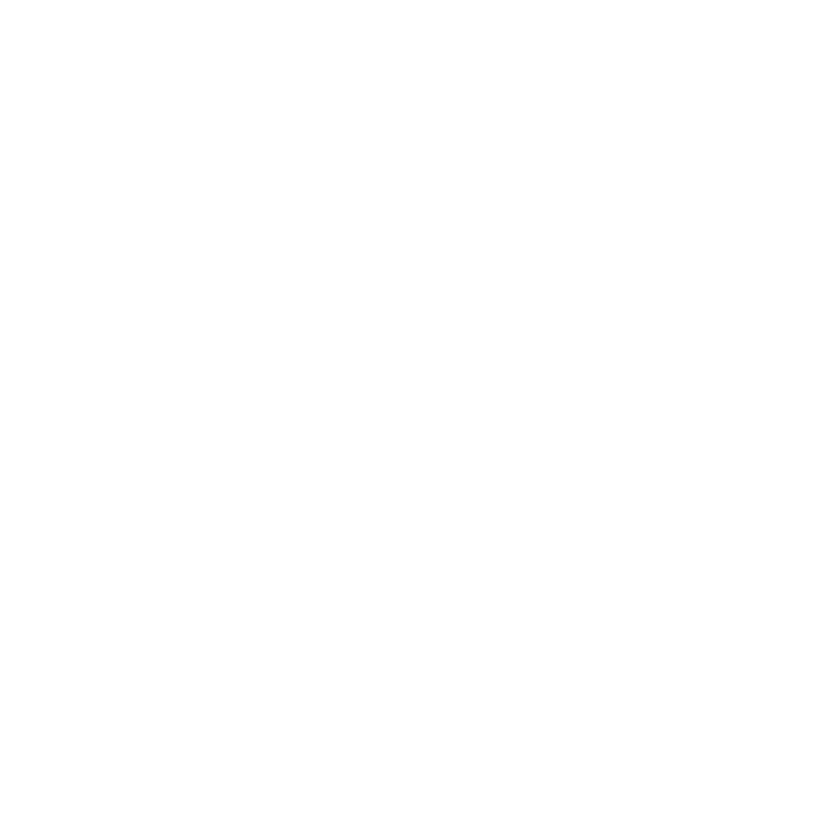

In [2]:
import os
import glob
import pandas as pd
import deeplabcut

# --- Paths ---
PROJECT_PATH = '/mnt/Data/Projects/cloud_deployment/Scripts/Stage2_Redux-Dev-2026-03-31'
CONFIG_PATH = os.path.join(PROJECT_PATH, 'config.yaml')
DYNAMIC_VIDEO = '/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_crop.mp4'
OFFSETS_CSV = '/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/crop_offsets.csv'

# --- 1. Evaluate the Model ---
print("📊 Evaluating network accuracy...")
deeplabcut.evaluate_network(CONFIG_PATH, plotting=True)

# --- 2. Analyze Video & Create Render ---
print("\n🧠 Running inference on the dynamic video...")
deeplabcut.analyze_videos(CONFIG_PATH, [DYNAMIC_VIDEO], save_as_csv=True)

print("🎬 Rendering the visual verification video...")
deeplabcut.create_labeled_video(CONFIG_PATH, [DYNAMIC_VIDEO], draw_skeleton=True)

# --- 3. Projection Mapping (Back to 4K) ---
print("\n🗺️ Mapping coordinates back to 4K absolute space...")
bodyparts = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']
video_dir = os.path.dirname(DYNAMIC_VIDEO)
video_name = os.path.splitext(os.path.basename(DYNAMIC_VIDEO))[0]

# Load the rolling offsets generated during the dynamic crop phase
offsets_df = pd.read_csv(OFFSETS_CSV)

# Find the newly generated tracking CSV
s2_csv_files = glob.glob(os.path.join(video_dir, f'{video_name}DLC*.csv'))
s2_track_csv = max(s2_csv_files, key=os.path.getctime)

df_s2 = pd.read_csv(s2_track_csv, header=[0, 1, 2], index_col=0)
scorer = df_s2.columns[0][0] 

# Apply the offsets
for bp in bodyparts:
    df_s2[(scorer, bp, 'x')] += offsets_df['x_offset'].values
    df_s2[(scorer, bp, 'y')] += offsets_df['y_offset'].values
    
final_out = os.path.join(video_dir, 'FINAL_ABSOLUTE_TRACKING.csv')
df_s2.to_csv(final_out)

print(f"\n🎉 DONE! Absolute tracking data saved to:\n{final_out}")

In [4]:
import cv2
import os

video_path = '/mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_cropDLC_effnet_b0_Stage2_ReduxMar31shuffle1_80000_labeled.mp4'
gif_path = video_path.replace('.mp4', '_sample.gif')

# Calculate the exact middle of the video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration = frames / fps
cap.release()

# Start 7.5 seconds before the midpoint to get a 15-second centered clip
start_time = max(0, (duration / 2) - 20)

print(f"🎬 Extracting 15s GIF starting at {start_time:.2f}s...")

# Uses ffmpeg to generate a high-quality color palette for the GIF
cmd = f'ffmpeg -hide_banner -loglevel error -y -ss {start_time:.2f} -t 15 -i "{video_path}" -vf "fps=15,scale=600:-1:flags=lanczos,split[s0][s1];[s0]palettegen[p];[s1][p]paletteuse" -loop 0 "{gif_path}"'
os.system(cmd)

print(f"✅ GIF saved to: {gif_path}")

🎬 Extracting 15s GIF starting at 63.13s...
✅ GIF saved to: /mnt/Data/Projects/cloud_deployment/videos/20260318_SERedt/20260318SER_dynamic_cropDLC_effnet_b0_Stage2_ReduxMar31shuffle1_80000_labeled_sample.gif
